In [1]:
import numpy as np

sobol_state = 'sobol_state.npy'
sobol_sample = "sobol_samples.npy"

# Chargement des données avec l'autorisation pickle
data1 = np.load(sobol_state, allow_pickle=True)
data2 = np.load(sobol_sample, allow_pickle=True)

print(data1)
print(data2)

16384
[{'ALPHA_STAR': np.float64(0.14654421154409647), 'F_STAR10': np.float64(-0.5568960830569267), 'F_ESC10': np.float64(0.225651066750288), 'ALPHA_ESC': np.float64(-0.9198149731382728), 'M_TURN': np.float64(8.595878463238478), 't_STAR': np.float64(0.8398779975250363)}
 {'ALPHA_STAR': np.float64(0.8683624439872801), 'F_STAR10': np.float64(-2.4805234791710973), 'F_ESC10': np.float64(-1.9911487214267254), 'ALPHA_ESC': np.float64(0.039969812612980604), 'M_TURN': np.float64(9.776840955018997), 't_STAR': np.float64(0.36994096264243126)}
 {'ALPHA_STAR': np.float64(0.27037661196663976), 'F_STAR10': np.float64(-1.4132807543501258), 'F_ESC10': np.float64(-0.21544912084937096), 'ALPHA_ESC': np.float64(-0.4071343974210322), 'M_TURN': np.float64(9.315577005967498), 't_STAR': np.float64(0.01980763114988804)}
 ...
 {'ALPHA_STAR': np.float64(0.27047277335077524), 'F_STAR10': np.float64(-2.5779164861887693), 'F_ESC10': np.float64(-1.9968055821955204), 'ALPHA_ESC': np.float64(0.4761475217528641), 'M_T

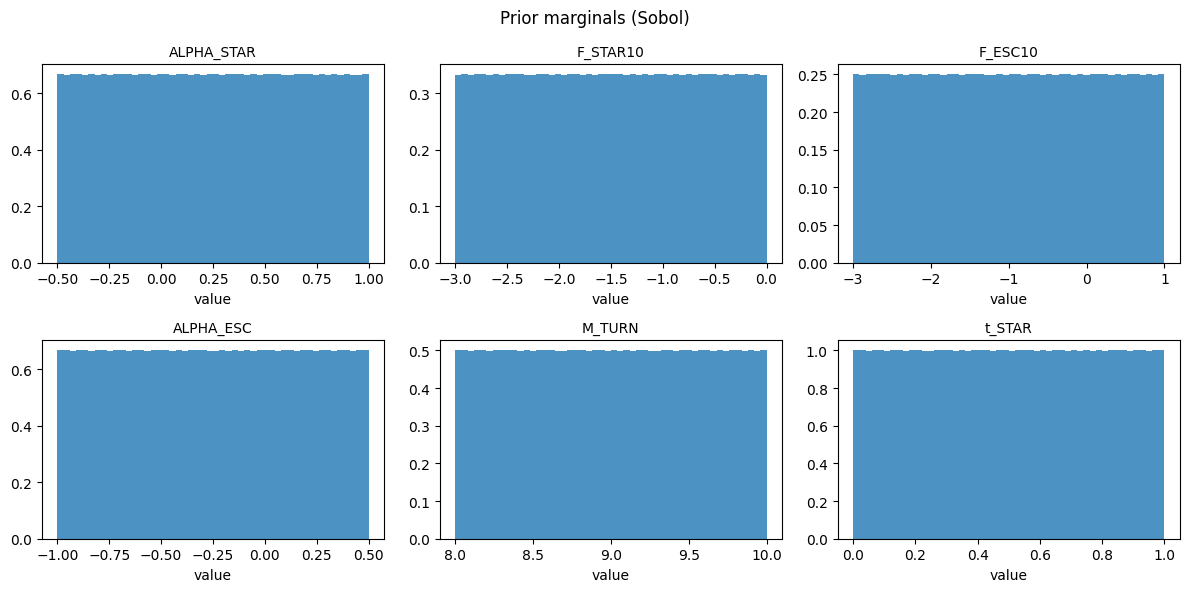

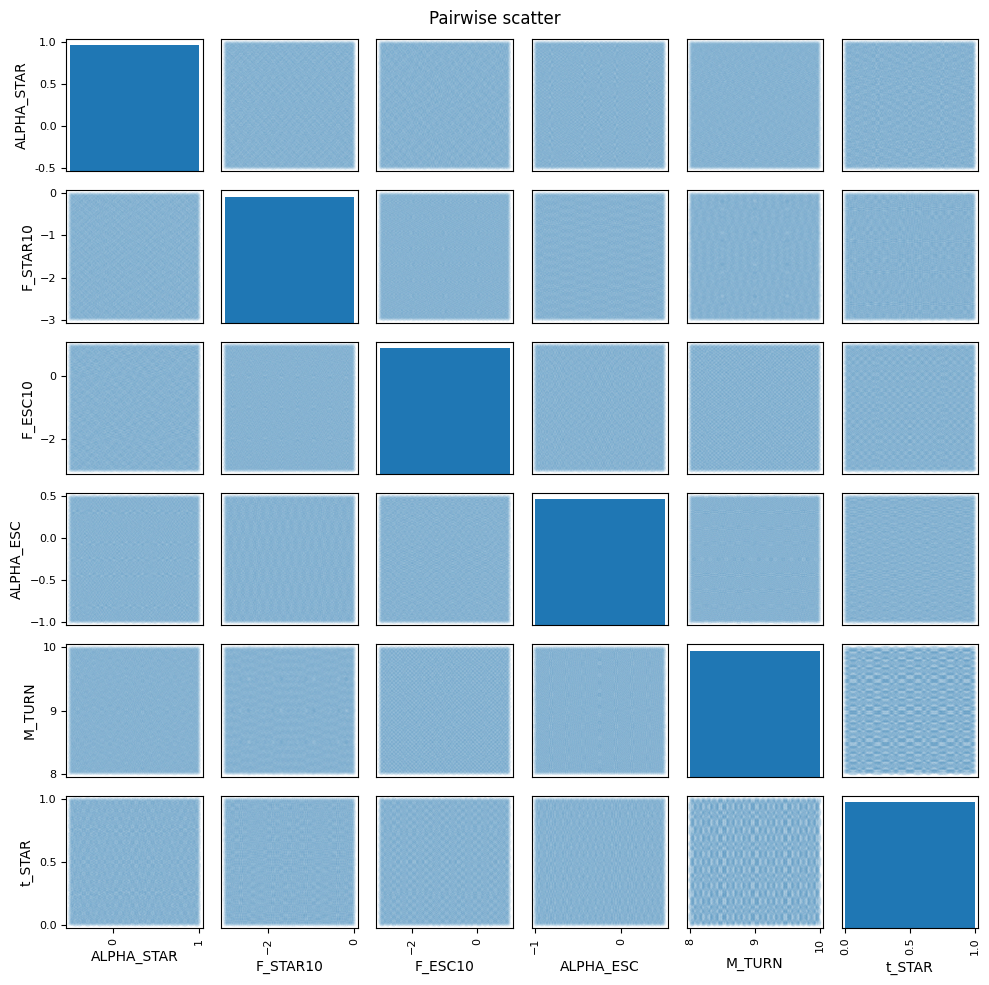

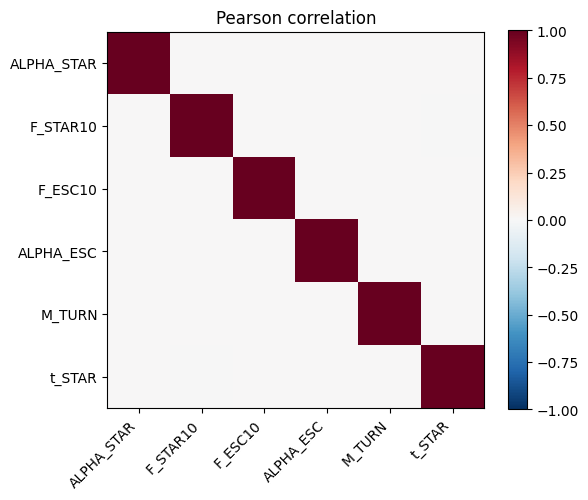

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parse les samples en DataFrame
samples = np.load("sobol_samples.npy", allow_pickle=True)
df = pd.DataFrame(list(samples))

params = df.columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# Marginals
for ax, col in zip(axes.flat, params):
    ax.hist(df[col], bins=50, density=True, alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("value")
plt.suptitle("Prior marginals (Sobol)")
plt.tight_layout()
plt.show()

# Scatter matrix
pd.plotting.scatter_matrix(df, figsize=(10, 10), alpha=0.05, diagonal='hist')
plt.suptitle("Pairwise scatter")
plt.tight_layout()
plt.show()

# Correlation matrix
fig, ax = plt.subplots(figsize=(6, 5))
corr = df.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(params))); ax.set_xticklabels(params, rotation=45, ha="right")
ax.set_yticks(range(len(params))); ax.set_yticklabels(params)
plt.colorbar(im, ax=ax)
plt.title("Pearson correlation")
plt.tight_layout()
plt.show()